In [1]:
%pip install numpy
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install joblib
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["species"] = iris.target

df["species"] = df["species"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

print("Iris dataset loaded successfully!")
print("Rows and columns:", df.shape)

display(df.head())

Iris dataset loaded successfully!
Rows and columns: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
print("Column names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Column names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'species']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB

Missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Duplicate rows: 1


In [5]:
display(df.describe(include="all").T)

print("\nSpecies distribution:")
display(df["species"].value_counts())

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,NaN,NaN,NaN,5.843333,0.828066,4.3,5.1,5.8,6.4,7.9
sepal width (cm),150.0,NaN,NaN,NaN,3.057333,0.435866,2.0,2.8,3.0,3.3,4.4
petal length (cm),150.0,NaN,NaN,NaN,3.758,1.765298,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,NaN,NaN,NaN,1.199333,0.762238,0.1,0.3,1.3,1.8,2.5
species,150,3,setosa,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Species distribution:


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

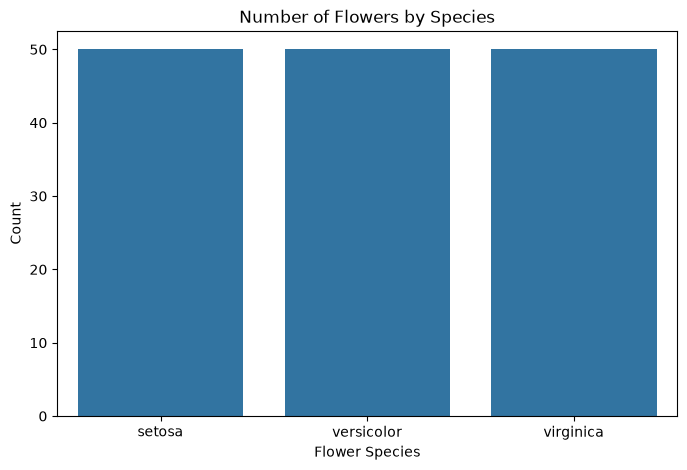

In [6]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="species"
)

plt.title("Number of Flowers by Species")
plt.xlabel("Flower Species")
plt.ylabel("Count")

plt.show()

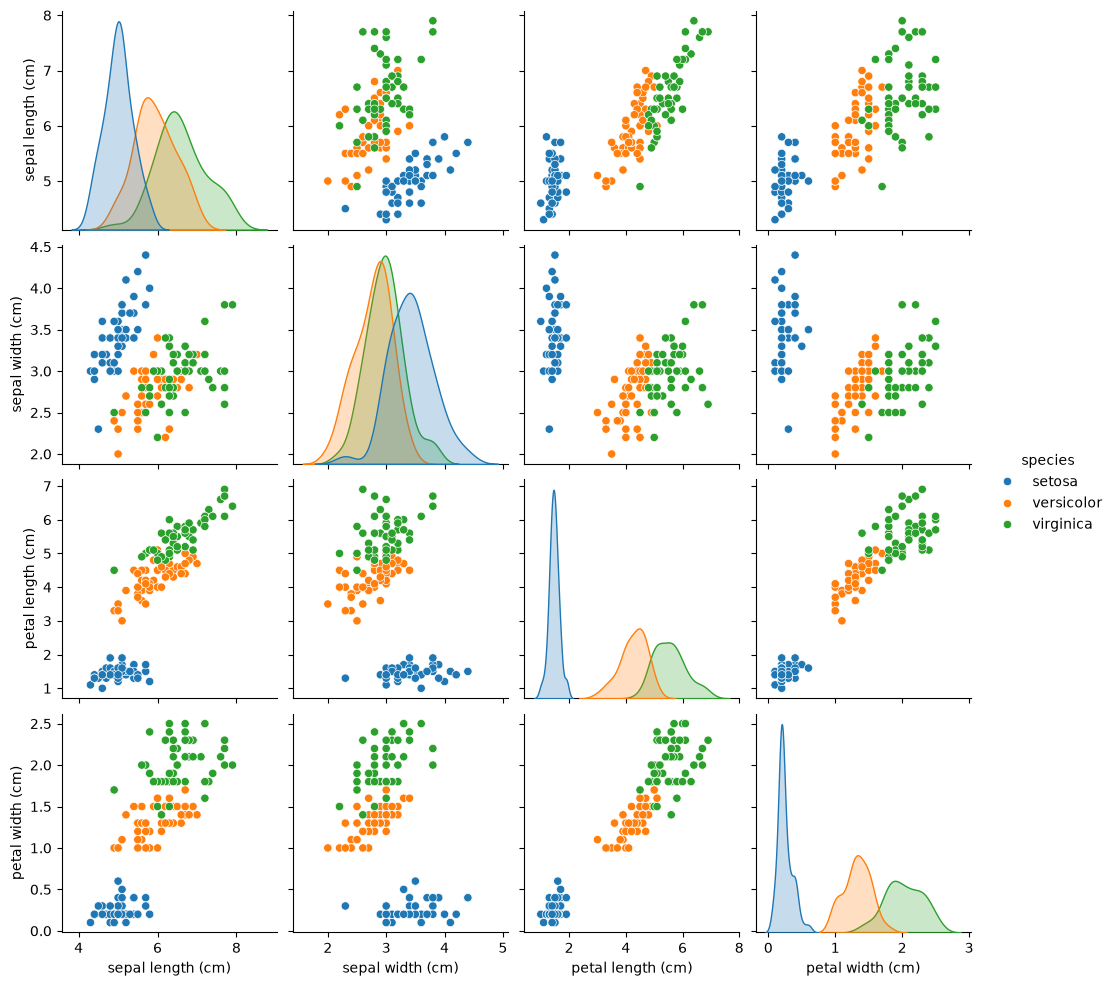

In [7]:
sns.pairplot(
    df,
    hue="species"
)

plt.show()

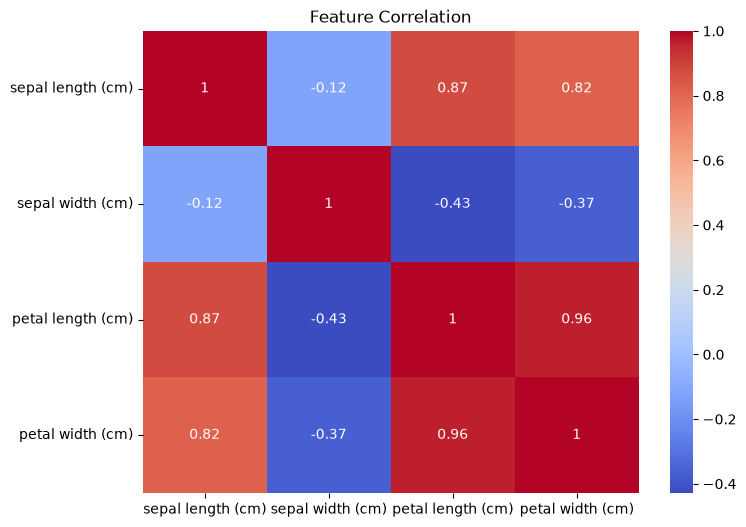

In [8]:
numeric_df = df.drop(columns=["species"])

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation")

plt.show()

In [9]:
features = [
    "sepal length (cm)",
    "sepal width (cm)",
    "petal length (cm)",
    "petal width (cm)"
]

target = "species"

X = df[features]
y = df[target]

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

Features:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



Target:


0    setosa
1    setosa
2    setosa
3    setosa
4    setosa
Name: species, dtype: str

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 120
Testing rows: 30


In [11]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [12]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
['setosa' 'virginica' 'versicolor' 'versicolor' 'setosa' 'versicolor'
 'setosa' 'setosa' 'virginica' 'versicolor' 'virginica' 'virginica'
 'virginica' 'versicolor' 'setosa' 'setosa' 'setosa' 'versicolor'
 'versicolor' 'versicolor' 'setosa' 'virginica' 'versicolor' 'versicolor'
 'virginica' 'virginica' 'versicolor' 'setosa' 'virginica' 'setosa']


In [13]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Model Accuracy: 0.9
Accuracy Percentage: 90.0 %


In [14]:
print("Classification Report:")

print(
    classification_report(
        y_test,
        y_pred
    )
)

Classification Report:


              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



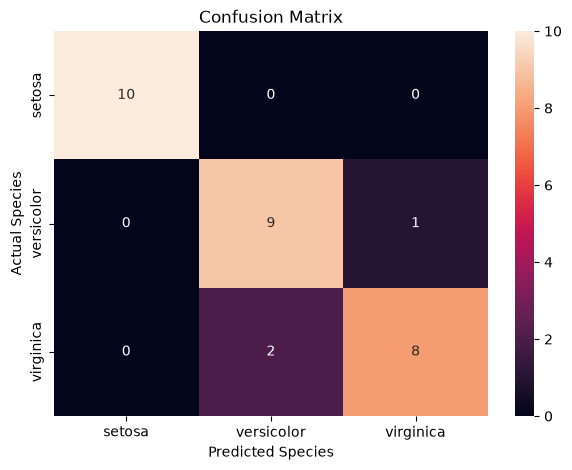

In [15]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")

plt.show()

In [16]:
joblib.dump(
    model,
    "iris_flower_prediction_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [17]:
loaded_model = joblib.load(
    "iris_flower_prediction_model.pkl"
)

print("Saved model loaded successfully!")

Saved model loaded successfully!


In [18]:
new_flower = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=features
)

prediction = loaded_model.predict(new_flower)

print("Predicted Flower Species:", prediction[0])

Predicted Flower Species: setosa
